In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc, roc_auc_score
from sklearn.preprocessing import StandardScaler

In [2]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# 输出数据集基本信息
print("数据集特征形状: ", X.shape)
print("数据集标签分布:\n", y.value_counts())

# 数据预处理：标准化特征数据
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 将标准化后的数据转换为DataFrame便于后续处理和可视化
X_scaled = pd.DataFrame(X_scaled, columns=data.feature_names)

# 2. 数据探索性分析（Exploratory Data Analysis, EDA）
# 分析数据集的基本统计量、相关性和分布情况，帮助我们更好地理解数据
print("\n数据集描述统计信息:\n", X.describe())

数据集特征形状:  (569, 30)
数据集标签分布:
 1    357
0    212
Name: count, dtype: int64

数据集描述统计信息:
        mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min

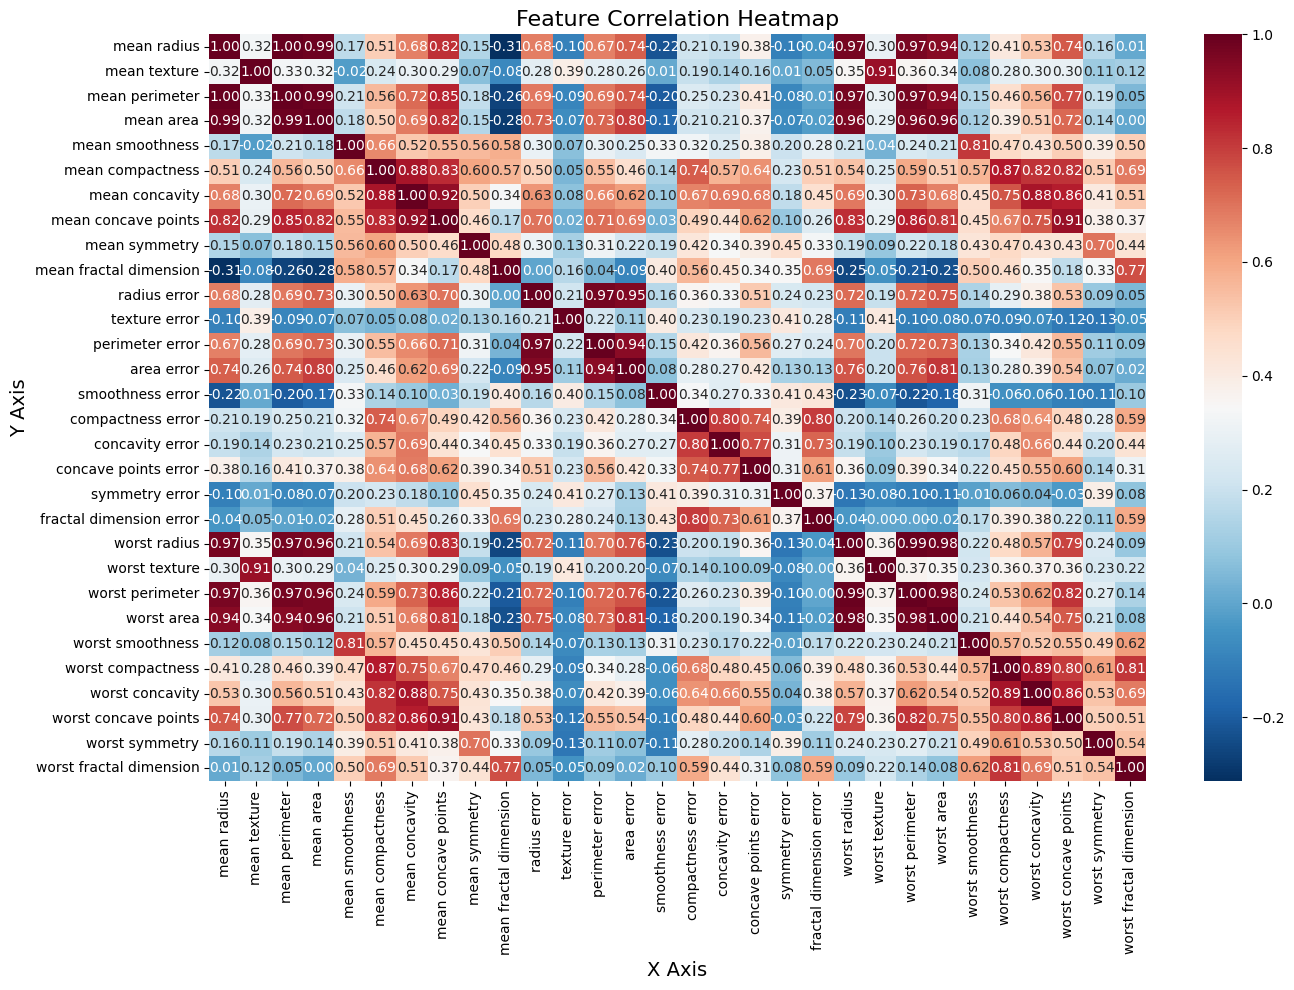

In [3]:
plt.figure(figsize=(14, 10))
corr = X.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r")
plt.title("Feature Correlation Heatmap", fontsize=16)
plt.xlabel("X Axis", fontsize=14)
plt.ylabel("Y Axis", fontsize=14)
plt.tight_layout()
plt.show()

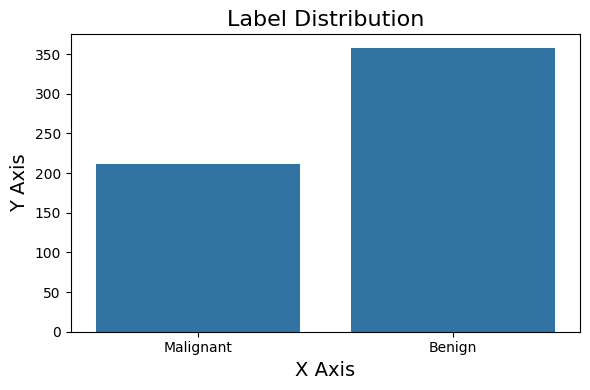

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(x=y)
plt.title("Label Distribution", fontsize=16)
plt.xlabel("X Axis", fontsize=14)
plt.ylabel("Y Axis", fontsize=14)
plt.xticks([0, 1], ['Malignant', 'Benign'])
plt.tight_layout()
plt.show()

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)
print("\n训练集样本数: ", X_train.shape[0])
print("测试集样本数: ", X_test.shape[0])


训练集样本数:  398
测试集样本数:  171


In [7]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

# 输出分类报告和混淆矩阵
print("\nInitial Model Classification Report:\n", classification_report(y_test, y_pred))
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)


Initial Model Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91        64
           1       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171

Confusion Matrix:
 [[ 58   6]
 [  5 102]]


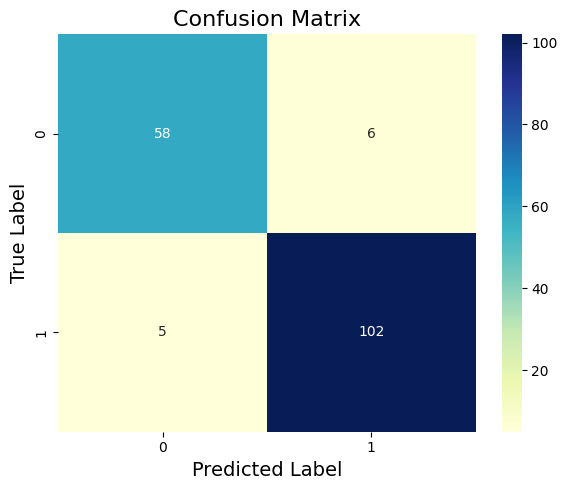

In [8]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGnBu", cbar=True)
plt.title("Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.tight_layout()
plt.show()

In [9]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

In [10]:
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid,
                           cv=5,
                           n_jobs=-1,
                           verbose=1,
                           scoring='accuracy')

# 训练调优
grid_search.fit(X_train, y_train)
print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Accuracy: {:.4f}".format(grid_search.best_score_))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits

Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 0.9725


In [11]:
best_rf = grid_search.best_estimator_
best_rf.fit(X_train, y_train)
y_pred_best = best_rf.predict(X_test)
print("\nOptimized Model Classification Report:\n", classification_report(y_test, y_pred_best))
cm_best = confusion_matrix(y_test, y_pred_best)
print("Optimized Confusion Matrix:\n", cm_best)


Optimized Model Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.91      0.91        64
           1       0.94      0.95      0.95       107

    accuracy                           0.94       171
   macro avg       0.93      0.93      0.93       171
weighted avg       0.94      0.94      0.94       171

Optimized Confusion Matrix:
 [[ 58   6]
 [  5 102]]


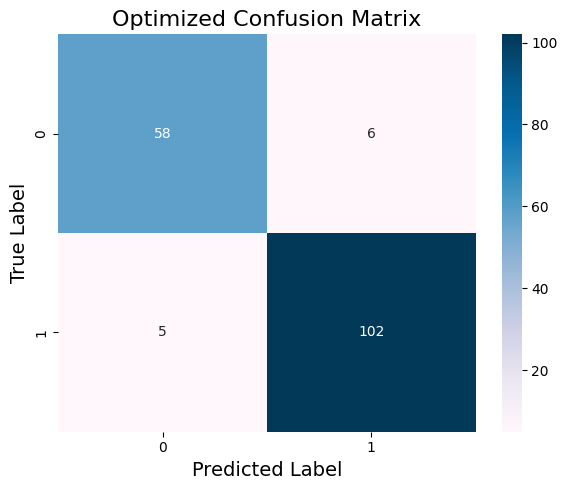

In [12]:
plt.figure(figsize=(6, 5))
sns.heatmap(cm_best, annot=True, fmt="d", cmap="PuBu", cbar=True)
plt.title("Optimized Confusion Matrix", fontsize=16)
plt.xlabel("Predicted Label", fontsize=14)
plt.ylabel("True Label", fontsize=14)
plt.tight_layout()
plt.show()

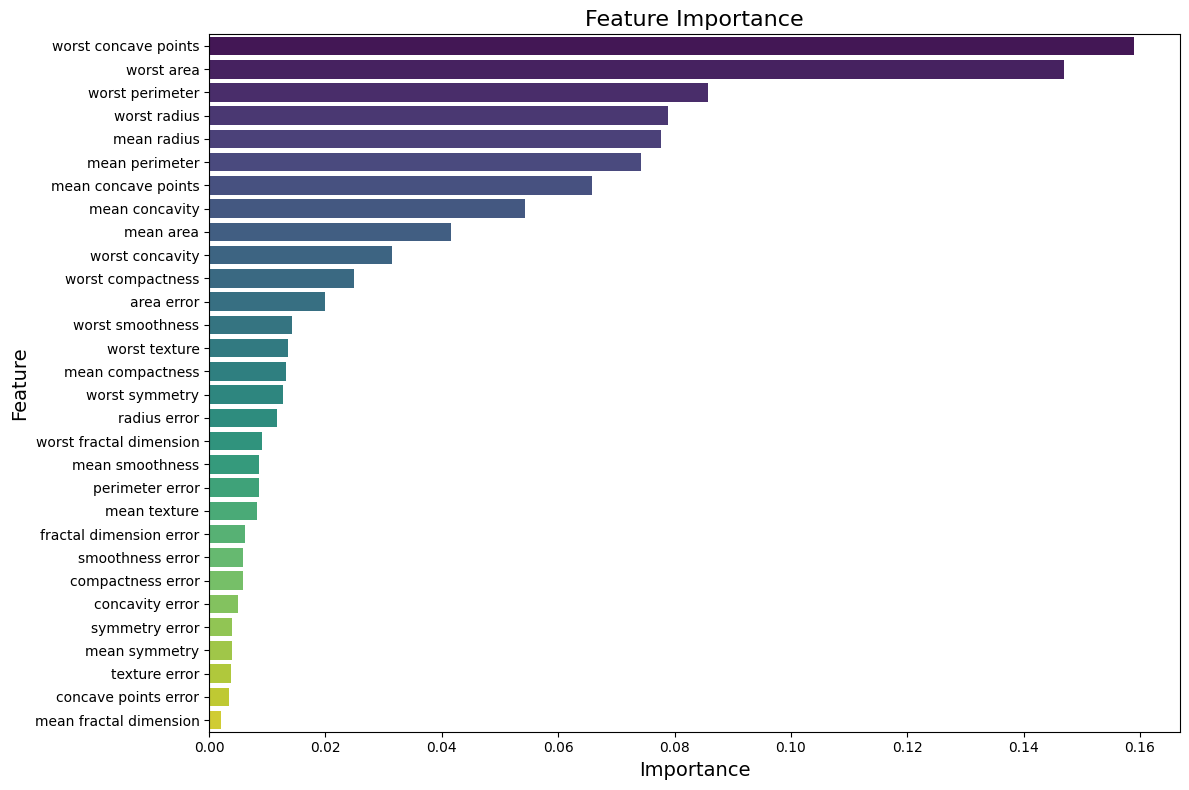

In [15]:
importances = best_rf.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns
plt.figure(figsize=(12, 8))
sns.barplot(x=importances[indices], y=features[indices], hue=features[indices], palette="viridis")
plt.title("Feature Importance", fontsize=16)
plt.xlabel("Importance", fontsize=14)
plt.ylabel("Feature", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
y_proba = best_rf.predict_proba(X_test)[:, 1]  # 获取正例概率
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)
print("\nOptimized Model ROC AUC: {:.4f}".format(roc_auc))


Optimized Model ROC AUC: 0.9913


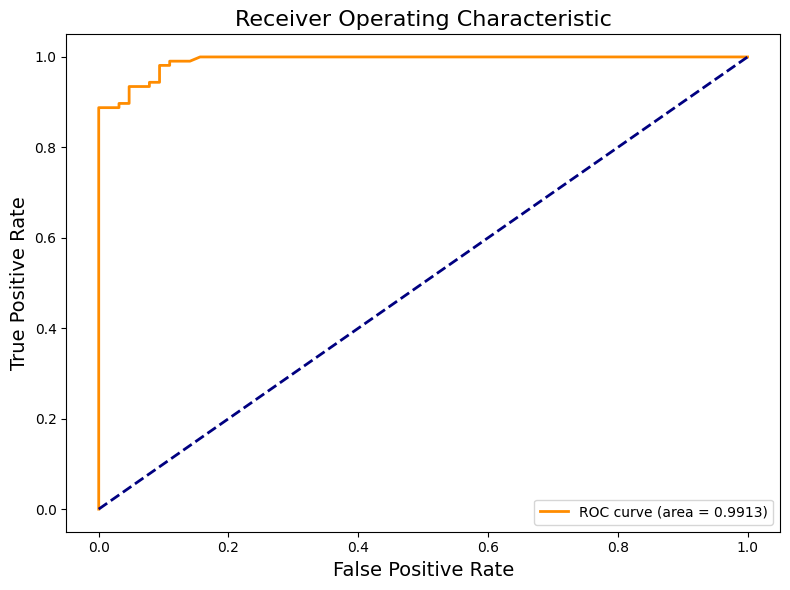

In [17]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.4f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.title("Receiver Operating Characteristic", fontsize=16)
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [18]:
cv_scores = cross_val_score(best_rf, X_scaled, y, cv=10, scoring='accuracy')
print("\nCross-validation Accuracy Scores:\n", cv_scores)
print("Mean CV Accuracy: {:.4f}".format(np.mean(cv_scores)))


Cross-validation Accuracy Scores:
 [0.98245614 0.89473684 0.94736842 0.94736842 1.         0.98245614
 0.94736842 0.98245614 0.94736842 1.        ]
Mean CV Accuracy: 0.9632


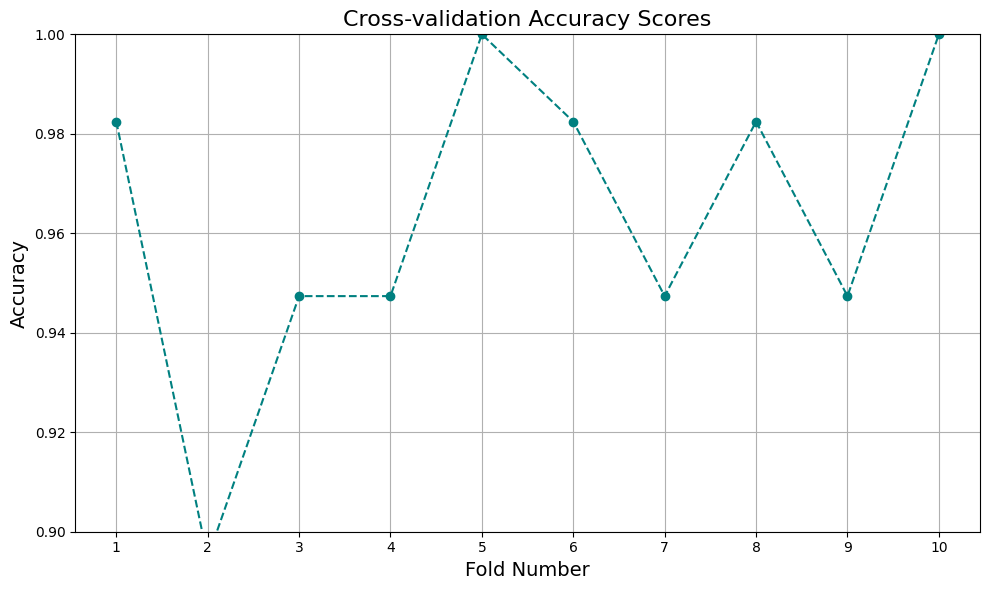

In [19]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), cv_scores, marker='o', linestyle='--', color='teal')
plt.title("Cross-validation Accuracy Scores", fontsize=16)
plt.xlabel("Fold Number", fontsize=14)
plt.ylabel("Accuracy", fontsize=14)
plt.xticks(range(1, 11))
plt.ylim(0.90, 1.00)
plt.grid(True)
plt.tight_layout()
plt.show()